In [1]:
import simpeg
print("SimPEG activate success, current edition：", simpeg.__version__)

SimPEG activate success, current edition： 0.25.1


In [2]:
# SimPEG functionality
from simpeg.electromagnetics.static import resistivity as dc
from simpeg import maps
from simpeg.utils import plot_1d_layer_model

# Common Python functionality
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({"font.size": 16})

write_output = False

In [3]:
# Define the 'a' spacings for Wenner array and number of soundings
a_min = 20.0
a_max = 500.0
n_stations = 25
electrode_separations = np.linspace(a_min, a_max, n_stations)

source_list = []   # Create an empty list for source objects.
for ii in range(0, len(electrode_separations)):
    # Extract separation parameter for sources and receivers
    a = electrode_separations[ii]

    # AB electrode locations for source. Each is a (1, 3) numpy array
    # actually each one is a (3,) numpy array
    A_location = np.r_[-1.5 * a, 0.0, 0.0]
    B_location = np.r_[1.5 * a, 0.0, 0.0]

    # MN electrode locations for receivers. Each is an (N, 3) numpy array
    # actually each one is a (3,) numpy array
    M_location = np.r_[-0.5 * a, 0.0, 0.0]
    N_location = np.r_[0.5 * a, 0.0, 0.0]

    # Create receivers list. Define as pole or dipole.
    receiver_list = dc.receivers.Dipole(
        M_location, N_location, data_type="apparent_resistivity"
    )
    receiver_list = [receiver_list]

    # Define the source properties and associated receivers
    source_list.append(dc.sources.Dipole(receiver_list, A_location, B_location))

# Define survey
survey = dc.Survey(source_list)

In [4]:
print("# of locations: {}".format(survey.nSrc))  # number of sources
print("# of data: {}".format(survey.nD))  # number of data that will be simulated
print(survey.source_list[3])   # The 4th source object (a = 80 m).
print(survey.source_list[3].receiver_list[0])  # Its receiver
print(A_location.shape)

# of locations: 25
# of data: 25
Dipole(a: [-120.    0.    0.]; b: [120.   0.   0.])
Dipole(m: [-40.   0.   0.]; n: [40.  0.  0.])
(3,)


In [5]:
# Define layer thicknesses.
layer_thicknesses = np.r_[100.0, 100.0]

# Define layer resistivities.
layer_resistivities = np.r_[1e3, 4e3, 2e2]

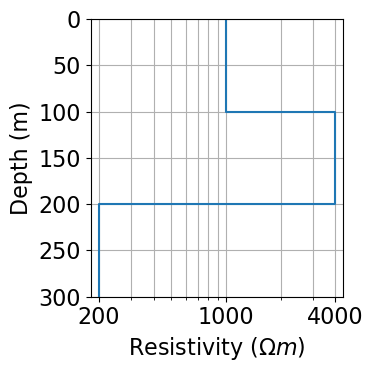

In [6]:
fig, ax = plt.subplots(figsize=(4, 4))
plot_1d_layer_model(layer_thicknesses, layer_resistivities, ax=ax)
ax.grid(which="both")
ax.set_xlabel(r"Resistivity ($\Omega m$)")
ax.set_xticks(layer_resistivities)
ax.set_xticklabels([f"{rho:g}" for rho in layer_resistivities])
fig.tight_layout()
plt.show()

### Now try simple sample of 1D forward modelling to understand the maps package in simpeg
### 1. Define Survey Geometry (ABMN)
Set up the $A, B, M, N$ electrode coordinates for the 1D DC resistivity survey.

### 2. Define 3-Layer Earth Model
Specify the true layer resistivities and layer thicknesses (with the 3rd layer extending to infinity).

### 3. Run 1D Forward Simulation
Configure the mapping and simulation engine to compute the predicted apparent resistivity ($\rho_a$).

### Now run the list of a(different distance of stations) to forward modelling

In [7]:
# Define mapping for a resistivity model.
resistivity_model = layer_resistivities.copy()
resistivity_map = maps.IdentityMap(nP=len(layer_resistivities))

# Define mappings for parametric model with log-resistivities
parametric_model = np.r_[layer_thicknesses, np.log(1 / layer_resistivities)]
wire_map = maps.Wires(
    ("thicknesses", len(layer_thicknesses)),
    ("log_conductivity", len(layer_resistivities)),
)
thicknesses_map = wire_map.thicknesses
log_conductivity_map = maps.ExpMap() * wire_map.log_conductivity

In [8]:
simulation_resistivity = dc.simulation_1d.Simulation1DLayers(
    survey=survey,
    rhoMap=resistivity_map,
    thicknesses=layer_thicknesses,
)
simulation_parametric = dc.simulation_1d.Simulation1DLayers(
    survey=survey,
    sigmaMap=log_conductivity_map,
    thicknessesMap=thicknesses_map,
)

In [9]:
dpred_resistivity = simulation_resistivity.dpred(resistivity_model)
dpred_parametric = simulation_parametric.dpred(parametric_model)
print(dpred_resistivity, dpred_parametric)


[1003.08512774 1021.99180575 1062.35290185 1119.18645437 1182.90390274
 1244.5209399  1297.78961703 1339.28904678 1367.76033096 1383.36185369
 1387.07542469 1380.29475502 1364.56267566 1341.41411745 1312.2894336
 1278.49101611 1241.1669197  1201.31055418 1159.76897319 1117.25442626
 1074.35802734 1031.56448247  989.26673181  947.77936294  907.35066671] [1003.08512774 1021.99180575 1062.35290185 1119.18645437 1182.90390274
 1244.5209399  1297.78961703 1339.28904678 1367.76033096 1383.36185369
 1387.07542469 1380.29475502 1364.56267566 1341.41411745 1312.2894336
 1278.49101611 1241.1669197  1201.31055418 1159.76897319 1117.25442626
 1074.35802734 1031.56448247  989.26673181  947.77936294  907.35066671]


### why when a == 20m, the rho is still 1003 not 1000?
first, as long as the distance existed between the two electrodes, there must be current go towards vertically into the deeper layer(rho == 4000 layer), as long as the first layer is limited depth, such as 100m, the second high resisticity layer has affected the current.
second, little diffenrece due to geometric spreading
### why the hankel is not the main problem?
hankel has already really small approximate value, 10 -e4, 1000 - 1003 == 3

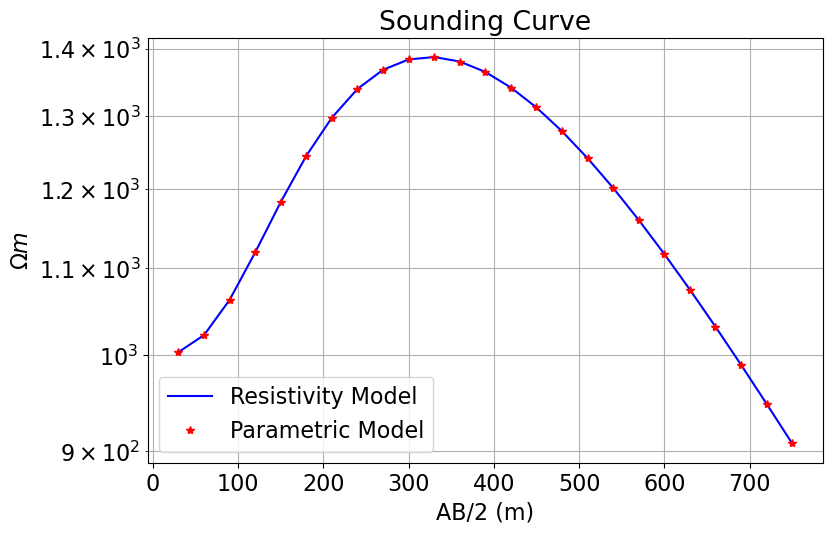

In [10]:
fig = plt.figure(figsize=(9, 5))
ax1 = fig.add_axes([0.1, 0.1, 0.75, 0.85])
ax1.semilogy(1.5 * electrode_separations, dpred_resistivity, "b")
ax1.semilogy(1.5 * electrode_separations, dpred_parametric, "r*")
ax1.grid(True, which="both")
ax1.set_xlabel("AB/2 (m)")
ax1.set_ylabel(r"$\Omega m$")
ax1.set_title("Sounding Curve")
ax1.legend(["Resistivity Model", "Parametric Model"])
plt.show()

### Compare sounding curves for varying equal layer thickness

Fixed resistivities: 1000–4000–200 Ω·m. First and second layer thickness are equal, from 50 m to 600 m in steps of 50 m. Each curve shows 25 discrete Wenner spacings as markers.

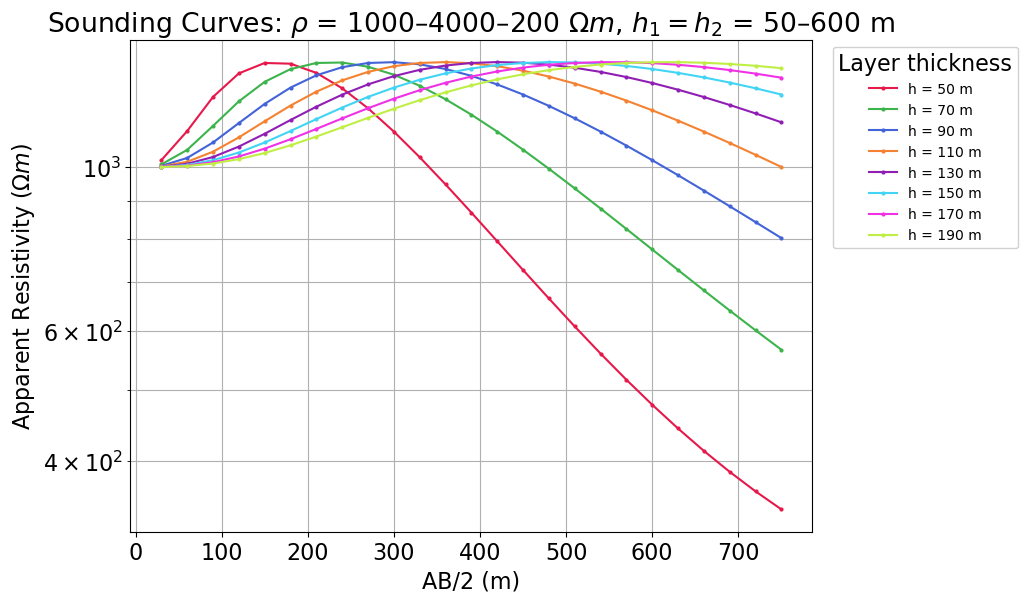

In [14]:
# Equal layer thicknesses: 50, 100, ..., 600 m
layer_depths = np.arange(50, 201, 20)
fixed_resistivities = np.r_[1e3, 4e3, 2e2]
resistivity_map = maps.IdentityMap(nP=len(fixed_resistivities))

# 25 discrete Wenner AB/2 spacings (one value per station)
ab_half = 1.5 * electrode_separations

distinct_colors = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
    "#42d4f4", "#f032e6", "#bfef45", "#469990", "#9A6324",
    "#800000", "#000075",
]

fig = plt.figure(figsize=(11, 6))
ax = fig.add_axes([0.1, 0.12, 0.62, 0.82])

for i, h in enumerate(layer_depths):
    thicknesses = np.r_[h, h]
    simulation = dc.simulation_1d.Simulation1DLayers(
        survey=survey,
        rhoMap=resistivity_map,
        thicknesses=thicknesses,
    )
    dpred = simulation.dpred(fixed_resistivities)
    color = distinct_colors[i % len(distinct_colors)]
    ax.semilogy(
        ab_half,
        dpred,
        color=color,
        marker="o",
        linestyle="-",
        markersize=2,
        label=f"h = {h:.0f} m",
    )

ax.grid(True, which="both")
ax.set_xlabel("AB/2 (m)")
ax.set_ylabel(r"Apparent Resistivity ($\Omega m$)")
ax.set_title(r"Sounding Curves: $\rho$ = 1000–4000–200 $\Omega m$, $h_1 = h_2$ = 50–600 m")
ax.legend(
    title="Layer thickness",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=10,
    framealpha=0.9,
)
plt.show()